# DeBERTa Results Comparison

Compare metrics across DeBERTa runs (zero-shot, few-shot, LoRA) from timestamped folders in `results/`.

In [73]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


In [ ]:
# All data loading and configuration for DeBERTa reports lives here.
REPORTS_DIR = Path("results")
FIGURES_DIR = REPORTS_DIR / "figures"
SAVE_FIGURES = False

MODEL_LABELS = {"zero_shot": "Zero-shot", "few_shot": "Few-shot", "lora": "LoRA"}

# Per-model subdirectories under reports/
MODEL_DIRS = {
    "zero_shot": REPORTS_DIR / "deberta_zero_shot",
    "few_shot": REPORTS_DIR / "deberta_few_shot",
    "lora": REPORTS_DIR / "deberta_lora",
}

# Filenames for test metrics and outputs inside each model directory
TEST_FILES = {
    "zero_shot": {
        "metrics": "deberta_zero_shot_test_metrics.json",
        "outputs": "deberta_zero_shot_test_outputs.json",
    },
    "few_shot": {
        "metrics": "deberta_few_shot_test_metrics.json",
        "outputs": "deberta_few_shot_test_outputs.json",
    },
    "lora": {
        "metrics": "deberta_lora_test_metrics.json",
        "outputs": "deberta_lora_test_outputs.json",
    },
}


def load_test_metrics(run_type: str) -> dict | None:
    base = MODEL_DIRS[run_type]
    path = base / TEST_FILES[run_type]["metrics"]
    return json.loads(path.read_text()) if path.exists() else None


def load_test_outputs(run_type: str) -> list | None:
    base = MODEL_DIRS[run_type]
    path = base / TEST_FILES[run_type]["outputs"]
    return json.loads(path.read_text()) if path.exists() else None


# Collect per-example test data for all models in a single pass
min_swaps_by_model: dict[str, list[float]] = {}
zero_one_acc_by_model: dict[str, list[float]] = {}

for run_type in MODEL_DIRS.keys():
    outputs = load_test_outputs(run_type)
    if outputs is None:
        continue

    min_swaps = [o["min_swaps"] for o in outputs if "min_swaps" in o]
    accuracies = [1.0 if o.get("correct", False) else 0.0 for o in outputs]

    if min_swaps:
        min_swaps_by_model[run_type] = min_swaps
    if accuracies:
        zero_one_acc_by_model[run_type] = accuracies

## Aggregate metrics comparison

Bar charts of zero-one accuracy, mean min swaps, and (when available) mean inference time by model and split.

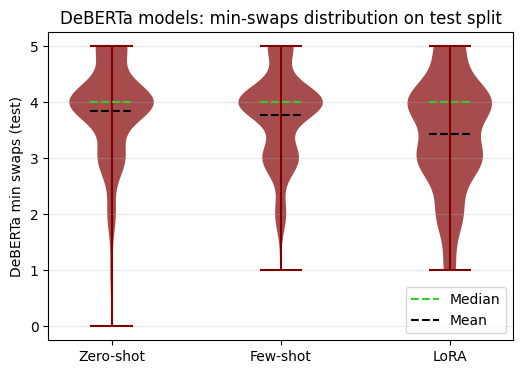

In [77]:
# DeBERTa min-swaps comparison on test split only
# We require all three DeBERTa variants to have data so the plot has 3 boxplots.
model_order = ["zero_shot", "few_shot", "lora"]

min_swaps_data = [min_swaps_by_model[m] for m in model_order]
labels = [MODEL_LABELS[m] for m in model_order]

plt.figure(figsize=(6, 4))
positions = np.arange(1, len(labels) + 1)

# Violin plot with built-in mean/median lines that span the violins
vp = plt.violinplot(
    min_swaps_data,
    positions=positions,
    showmeans=True,
    showmedians=True,
    showextrema=True,
)
vp['cmeans'].set_linestyle('--')
vp['cmeans'].set_color('black')
vp['cmeans'].set_linewidth(1.5)

vp['cmedians'].set_linestyle('--')
vp['cmedians'].set_color('limegreen')
vp['cmedians'].set_linewidth(1.5)

vp['cmins'].set_color('maroon')
vp['cmaxes'].set_color('maroon')

for body in vp['bodies']:
    body.set_facecolor('maroon')
    body.set_alpha(0.7) 
vp['cbars'].set_edgecolor('maroon')


plt.xticks(positions, labels)
plt.ylabel("DeBERTa min swaps (test)")
plt.title("DeBERTa models: min-swaps distribution on test split")
plt.grid(axis="y", alpha=0.3)

custom_lines = [
    Line2D([0], [0], color='limegreen', lw=1.5, linestyle='--'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--')
]
plt.legend(custom_lines, ['Median', 'Mean'], loc='best')

if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(
        FIGURES_DIR / "deberta_min_swaps_violin_test.png",
        bbox_inches="tight",
        dpi=200,
    )

plt.show()